<a href="https://colab.research.google.com/github/kellenmonteiroferreira-dev/analise_sono_estilo_vida.ipynb/blob/main/analise_sono_saude_vida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install kaggle

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Path to dataset files: /kaggle/input/sleep-health-and-lifestyle-dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv')
print(df.head())

   Person ID Gender  Age            Occupation  Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level BMI Category Blood Pressure  Heart Rate  Daily Steps Sleep Disorder
0          1   Male   27     Software Engineer             6.1                 6                       42             6   Overweight         126/83          77         4200            NaN
1          2   Male   28                Doctor             6.2                 6                       60             8       Normal         125/80          75        10000            NaN
2          3   Male   28                Doctor             6.2                 6                       60             8       Normal         125/80          75        10000            NaN
3          4   Male   28  Sales Representative             5.9                 4                       30             8        Obese         140/90          85         3000    Sleep Apnea
4          5   Male   28  Sales Representative             5

                              

---

---





Este projeto tem como objetivo analisar a relação entre fatores de estilo de vida e a qualidade do sono dos indivíduos. O sono é um dos principais indicadores de saúde e bem-estar, sendo influenciado por diversos aspectos como nível de estresse, atividade física, profissão e condições fisiológicas.

Através de técnicas de análise de dados, foram exploradas possíveis relações entre essas variáveis, buscando identificar padrões, tendências e fatores que impactam diretamente a qualidade do sono.



---



---
base de dados


---



A base de dados utilizada contém informações relacionadas ao estilo de vida e à saúde de diferentes indivíduos. Entre as principais variáveis disponíveis, destacam-se:

Gênero: masculino ou feminino

Idade: idade dos indivíduos

Profissão: ocupação profissional

Duração do Sono: número de horas dormidas por noite

Qualidade do Sono: avaliação do sono em escala numérica

Nível de Estresse: grau de estresse percebido

Nível de Atividade Física: intensidade de atividade física

Categoria do IMC: classificação do índice de massa corporal

Pressão Arterial: condição da pressão sanguínea

Frequência Cardíaca: batimentos por minuto

Passos Diários: nível de atividade diária

Distúrbios do Sono: presença de problemas relacionados ao sono

Esses dados permitem uma análise ampla, considerando tanto fatores comportamentais quanto fisiológicos.




---


 Objetivo da análise


---


O principal objetivo deste projeto é identificar quais fatores possuem maior influência na qualidade do sono, com foco em:

Relação entre estresse e sono

Impacto da duração do sono na qualidade

Diferenças entre gêneros e profissões

Influência de fatores de saúde e estilo de vida.




###  Limpeza e Preparação dos Dados

In [ ]:
# Dicionário de tradução das colunas
traducao_colunas = {
    "Person ID": "ID da Pessoa",
    "Gender": "Gênero",
    "Age": "Idade",
    "Occupation": "Profissão",
    "Sleep Duration": "Duração do Sono (horas)",
    "Quality of Sleep": "Qualidade do Sono",
    "Physical Activity Level": "Nível de Atividade Física",
    "Stress Level": "Nível de Estresse",
    "BMI Category":	"Categoria de IMC",
    "Blood Pressure":	"Pressão Arterial",
    "Heart Rate":	"Frequência Cardíaca",
    "Daily Steps":	"Passos Diários",
    "Sleep Disorder":	"Distúrbio do Sono"
    }

    # Renomear colunas
df_renomear = df.rename(columns=traducao_colunas)
print(df_renomear.head())

# configura exibição do df
pd.set_option('display.max_columns', None) # todas as colunas
pd.set_option('display.width', 1000) # ajusta a largura com a tela

print(df_renomear.head())

   ID da Pessoa Gênero  Idade             Profissão  Duração do Sono (horas)  Qualidade do Sono  Nível de Atividade Física  Nível de Estresse Categoria de IMC Pressão Arterial  Frequência Cardíaca  Passos Diários Distúrbio do Sono
0             1   Male     27     Software Engineer                      6.1                  6                         42                  6       Overweight           126/83                   77            4200               NaN
1             2   Male     28                Doctor                      6.2                  6                         60                  8           Normal           125/80                   75           10000               NaN
2             3   Male     28                Doctor                      6.2                  6                         60                  8           Normal           125/80                   75           10000               NaN
3             4   Male     28  Sales Representative                      5.9

Remoção de colunas irrelevantes para a análise, como identificador único (ID) e passos diários.

In [ ]:
df_renomear = df_renomear.drop(columns=['ID da Pessoa', 'Passos Diários'])

In [ ]:
# inspecionar dados
print(df_renomear.head())
print(df_renomear.info())
print(df_renomear.describe())

  Gênero  Idade             Profissão  Duração do Sono (horas)  Qualidade do Sono  Nível de Atividade Física  Nível de Estresse Categoria de IMC Pressão Arterial  Frequência Cardíaca Distúrbio do Sono
0   Male     27     Software Engineer                      6.1                  6                         42                  6       Overweight           126/83                   77               NaN
1   Male     28                Doctor                      6.2                  6                         60                  8           Normal           125/80                   75               NaN
2   Male     28                Doctor                      6.2                  6                         60                  8           Normal           125/80                   75               NaN
3   Male     28  Sales Representative                      5.9                  4                         30                  8            Obese           140/90                   85       Sleep A

In [ ]:
agrupar = df_renomear.groupby(['Idade', 'Gênero']).size().unstack(fill_value=0) # contar ocorrencia e transformar em tabela, preenche onde não houver dados

# Exibir a tabela pivotada
display(agrupar)

Gênero,Female,Male
Idade,,
27,0,1
28,0,5
29,2,11
30,2,11
31,1,17
32,0,17
33,2,11
34,2,0
35,1,11


### Análise exploratória

Distribuição por Gênero

In [ ]:
contagem = df_renomear['Gênero'].value_counts() # contar por genero
percentual = df_renomear['Gênero'].value_counts(normalize=True) * 100 # porcentagem

tabela = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual
})

display(tabela)

,Quantidade,Percentual (%)
Gênero,,
Male,189,50.534759
Female,185,49.465241


In [ ]:
agrupar = df_renomear.groupby(['Gênero', 'Duração do Sono (horas)']).size() # agrupar po genero e duração do sono

display(agrupar)

Gênero  Duração do Sono (horas)
Female  5.8                         2
        5.9                         1
        6.0                        13
        6.1                        15
        6.2                         6
        6.4                         2
        6.5                        12
        6.6                        18
        6.7                         3
        6.8                         4
        6.9                         2
        7.1                        13
        7.2                        22
        7.4                         1
        7.5                         1
        7.9                         1
        8.0                        13
        8.1                        13
        8.2                        11
        8.3                         5
        8.4                        14
        8.5                        13
Male    5.9                         3
        6.0                        18
        6.1                        10
        6.2                         6
        6.3                        13
        6.4                         7
        6.5                        14
        6.6                         2
        6.7                         2
        6.8                         1
        6.9                         1
        7.1                         6
        7.2                        14
        7.3                        14
        7.4                         4
        7.5                         4
        7.6                        10
        7.7                        24
        7.8                        28
        7.9                         6
        8.1                         2
dtype: int64

Observa-se uma distribuição equilibrada entre os gêneros.

 A presença de distúbios do sono está associada a um nível mais elevado de estresse.

In [ ]:
# Agrupando distúbio do sono e nível de estresse

df_renomear.groupby('Distúrbio do Sono')['Nível de Estresse'].mean()

,Nível de Estresse
Distúrbio do Sono,
Insomnia,5.870130
Sleep Apnea,5.666667


#Correlacionando a qualidade do sono com a duração do sono   

 Foi identificada uma forte correlação positiva (0.88) entre a duração do sono e sua qualidade,
 indicando que indivíduos que dormem mais tendem a apresentar melhor qualidade de sono.

In [ ]:
df_renomear[['Duração do Sono (horas)', 'Qualidade do Sono']].corr()

,Duração do Sono (horas),Qualidade do Sono
Duração do Sono (horas),1.000000,0.883213
Qualidade do Sono,0.883213,1.000000


Text(0.5, 1.0, 'Relação entre Duração do Sono (horas) e Qualidade do Sono')

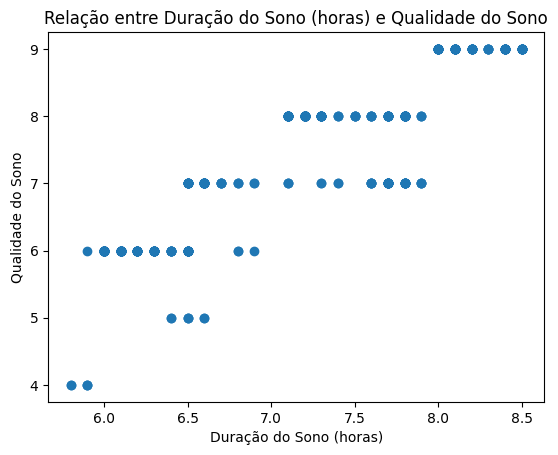

In [ ]:
# Gráfico de correlação entre horas de sono e qualidade do sono
plt.scatter(
    df_renomear['Duração do Sono (horas)'],
    df_renomear['Qualidade do Sono']
)

plt.xlabel('Duração do Sono (horas)')
plt.ylabel('Qualidade do Sono')
plt.title('Relação entre Duração do Sono (horas) e Qualidade do Sono')

#Correlacionando o estresse com a qualidade do sono

Foi identificada uma forte correlação negativa (-0.89) entre o nível de estresse e a qualidade do sono,
indicando que indivíduos mais estressados tendem a apresentar pior qualidade de sono.

In [ ]:
df_renomear[['Nível de Estresse', 'Qualidade do Sono']].corr()

,Nível de Estresse,Qualidade do Sono
Nível de Estresse,1.000000,-0.898752
Qualidade do Sono,-0.898752,1.000000


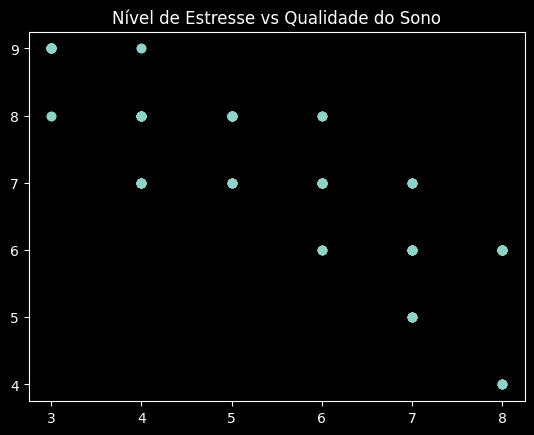

In [ ]:
plt.scatter(df_renomear['Nível de Estresse'], df_renomear['Qualidade do Sono'])
plt.title('Nível de Estresse vs Qualidade do Sono')
plt.show()

#Correlacionando a qualidade do sono e a frequência cardíaca

Observa-se uma correlação negativa moderada (-0.66) entre a qualidade do sono e a frequência cardíaca,
sugerindo que indivíduos com melhor qualidade de sono tendem a apresentar menor frequência cardíaca,
possivelmente indicando melhor recuperação e estado fisiológico.

In [ ]:
df_renomear[['Qualidade do Sono', 'Frequência Cardíaca']].corr()


,Qualidade do Sono,Frequência Cardíaca
Qualidade do Sono,1.000000,-0.659865
Frequência Cardíaca,-0.659865,1.000000


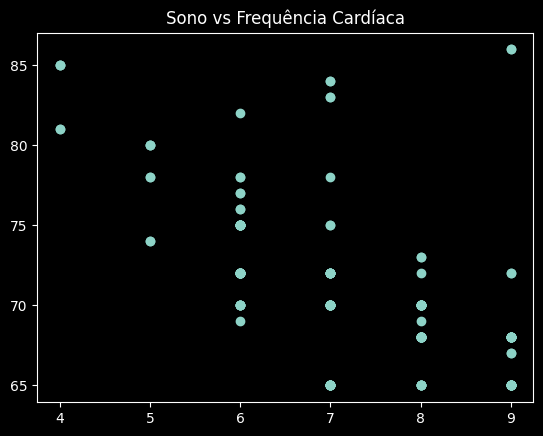

In [ ]:
plt.scatter(df_renomear['Qualidade do Sono'], df_renomear['Frequência Cardíaca'])
plt.title('Sono vs Frequência Cardíaca')
plt.show()

# Correlacionando a duração do sono e a frequência cardíaca
Os resultados indicam que tanto a duração quanto a qualidade do sono estão associadas a indicadores fisiológicos,
 como a frequência cardíaca, sugerindo impacto direto do sono na recuperação do organismo.


In [ ]:
df_renomear[['Frequência Cardíaca', 'Duração do Sono (horas)']].corr()

,Frequência Cardíaca,Duração do Sono (horas)
Frequência Cardíaca,1.000000,-0.516455
Duração do Sono (horas),-0.516455,1.000000


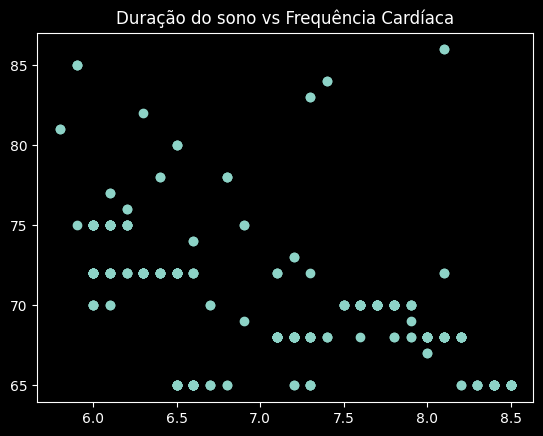

In [ ]:
# Duração do sono e frequência cardíaca
plt.scatter(df_renomear['Duração do Sono (horas)'], df_renomear['Frequência Cardíaca'])
plt.title('Duração do sono vs Frequência Cardíaca')
plt.show()

In [ ]:
# Profissçao que tem maior risco
df_renomear.groupby('Profissão')[['Qualidade do Sono', 'Nível de Estresse']].mean()


,Qualidade do Sono,Nível de Estresse
Profissão,,
Accountant,7.891892,4.594595
Doctor,6.647887,6.732394
Engineer,8.412698,3.888889
Lawyer,7.893617,5.063830
Manager,7.000000,5.000000
Nurse,7.369863,5.547945
Sales Representative,4.000000,8.000000
Salesperson,6.000000,7.000000
Scientist,5.000000,7.000000


# Diferença entre homens e mulheres com realação a qualidade do sono
Percebeu -se que a qualidade dos sono é menor para homens do que para mulheres.
e nível de estresse segue o mesmo raciocínio, Indivíduos do gênero feminino apresentam, em média,
melhor qualidade do sono e menores níveis de estresse quando comparados ao gênero masculino.

In [ ]:
df_renomear.groupby('Gênero')[['Qualidade do Sono', 'Nível de Estresse']].mean()


,Qualidade do Sono,Nível de Estresse
Gênero,,
Female,7.664865,4.675676
Male,6.968254,6.079365


# Mapa de calor


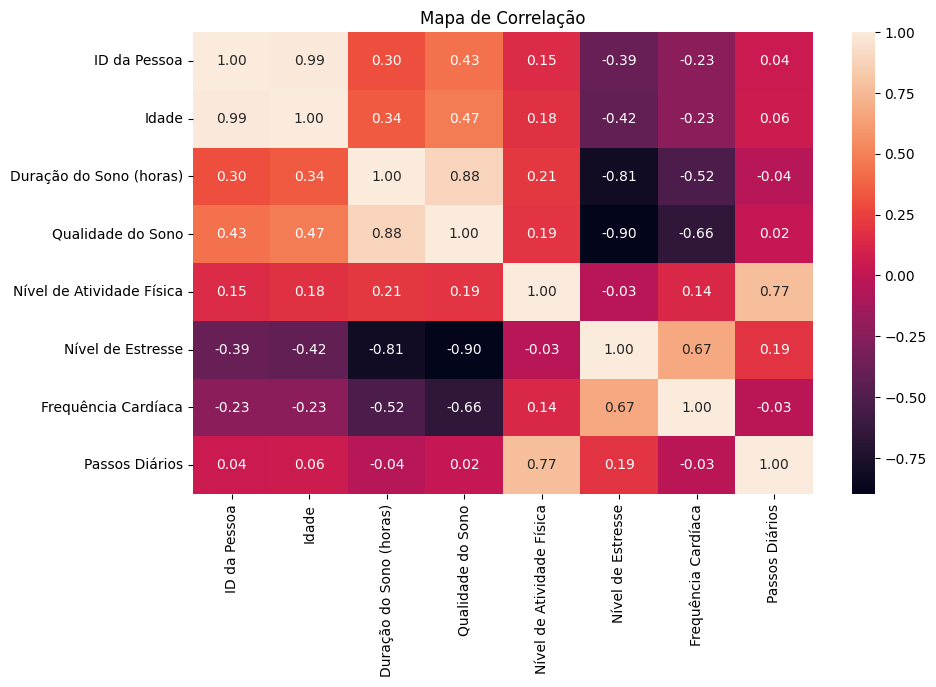

In [ ]:
# Seleciona apenas colunas numéricas
corr = df_renomear.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Mapa de Correlação')
plt.show()

### O mapa de correlação evidencia que o nível de estresse apresenta forte relação negativa com a qualidade do sono, enquanto a duração do sono possui relação positiva significativa. Outras variáveis demonstram menor influência isolada.”

# Agrupar estresse e IMC
 Indivíduos com o nível de estresse mais alto tendem a ter um IMC mais elevado.


In [ ]:
df_renomear.groupby('Categoria de IMC')['Nível de Estresse'].mean()

,Nível de Estresse
Categoria de IMC,
Normal,5.128205
Normal Weight,5.190476
Obese,5.700000
Overweight,5.729730


# Agrupar qualidade do sono e categoria de IMC
Indivíduos com um IMC mais elevado tendem a apresentar menor qualidade do sono.

In [ ]:
df_renomear.groupby('Categoria de IMC')['Qualidade do Sono'].mean().sort_values(ascending=False)

,Qualidade do Sono
Categoria de IMC,
Normal,7.661538
Normal Weight,7.428571
Overweight,6.898649
Obese,6.400000


# Agrupando distúbio do sono e nível de estresse

 A presença de distúbios do sono está associada a um nível mais elevado de estresse.


In [ ]:
df_renomear.groupby('Distúrbio do Sono')['Nível de Estresse'].mean()

,Nível de Estresse
Distúrbio do Sono,
Insomnia,5.870130
Sleep Apnea,5.666667


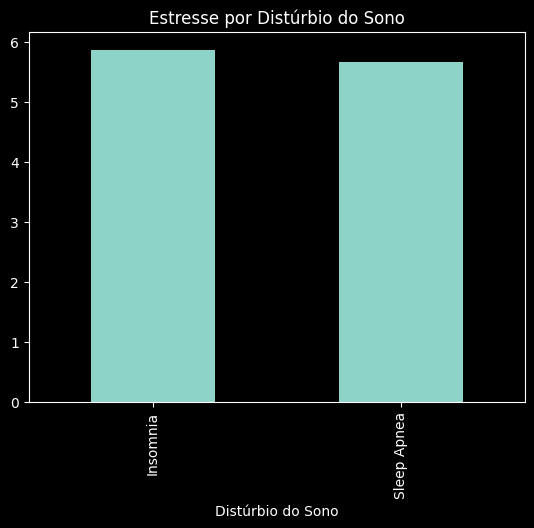

In [ ]:
# Grafico do distúrbio do sono e estresse

df_renomear.groupby('Distúrbio do Sono')['Nível de Estresse'].mean().plot(kind='bar')
plt.title('Estresse por Distúrbio do Sono')
plt.show()

# Agrupando nível de estresse e pressão arterial
 Indivíduos com um nível de estresse mais alto tendem a ter uma pressão arterial mais alta.

In [ ]:
df_renomear.groupby('Pressão Arterial')['Nível de Estresse'].mean()

,Nível de Estresse
Pressão Arterial,
115/75,4.000000
115/78,3.000000
117/76,5.500000
118/75,3.000000
118/76,6.000000
119/77,6.000000
120/80,5.955556
121/79,6.000000
122/80,4.000000


# Agrupando gênero e qualidade do sono

In [ ]:
df_renomear.groupby('Gênero')['Qualidade do Sono'].mean()

,Qualidade do Sono
Gênero,
Female,7.664865
Male,6.968254


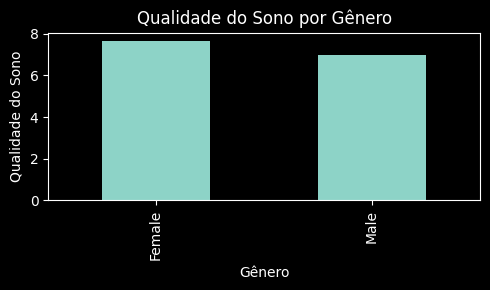

In [ ]:
# Grafico Qualidade do sono e gênero

plt.style.use('dark_background')  # fundo preto

df_renomear.groupby('Gênero')['Qualidade do Sono'].mean().plot(
    kind='bar',
    figsize=(5,3)  # tamanho do grafico pequeno
)

plt.title('Qualidade do Sono por Gênero', color='white')
plt.xlabel('Gênero', color='white')
plt.ylabel('Qualidade do Sono', color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

# Agrupando por profissão e gênero

In [ ]:
df_renomear.groupby(['Profissão', 'Gênero']).size()

Profissão             Gênero
Accountant            Female    36
                      Male       1
Doctor                Female     2
                      Male      69
Engineer              Female    32
                      Male      31
Lawyer                Female     2
                      Male      45
Manager               Female     1
Nurse                 Female    73
Sales Representative  Male       2
Salesperson           Male      32
Scientist             Female     4
Software Engineer     Male       4
Teacher               Female    35
                      Male       5
dtype: int64

# Agrupando profissóes com maior nível de estress e distúbios do sono em ordem decrescente

In [ ]:
df_renomear.groupby(['Profissão', 'Distúrbio do Sono'])['Nível de Estresse'].mean().sort_values(ascending=False)


Profissão             Distúrbio do Sono
Scientist             Sleep Apnea          8.000000
Software Engineer     Insomnia             8.000000
Sales Representative  Sleep Apnea          8.000000
Nurse                 Insomnia             7.333333
Salesperson           Insomnia             7.000000
                      Sleep Apnea          7.000000
Accountant            Insomnia             6.571429
Teacher               Sleep Apnea          6.250000
Doctor                Insomnia             6.000000
Nurse                 Sleep Apnea          5.540984
Engineer              Insomnia             5.400000
Doctor                Sleep Apnea          5.000000
Lawyer                Sleep Apnea          5.000000
                      Insomnia             5.000000
Engineer              Sleep Apnea          5.000000
Teacher               Insomnia             4.370370
Name: Nível de Estresse, dtype: float64

#### O gráfico representa montante de profissões

In [ ]:
# Criar o top 5
top_5 = df_renomear.groupby('Profissão')['Nível de Estresse'] \
    .mean().sort_values(ascending=False).head(5).reset_index()

# Criar gráfico interativo
fig = px.bar(
    top_5,
    x='Profissão',
    y='Nível de Estresse',
    title='Top 5 Profissões Mais Estressantes',
    color='Nível de Estresse'
)

fig.show()

### “Embora algumas profissões apresentem níveis elevados de estresse em casos específicos associados a distúrbios do sono, a média geral indica que esse comportamento não é uniforme entre todos os indivíduos da mesma profissão.”

#### Exclui pessoas sem distúrbio

In [ ]:
df_renomear.groupby(['Profissão', 'Distúrbio do Sono'])['Nível de Estresse'] \
    .mean().sort_values(ascending=False).head(5)

,,Nível de Estresse
Profissão,Distúrbio do Sono,
Scientist,Sleep Apnea,8.000000
Software Engineer,Insomnia,8.000000
Sales Representative,Sleep Apnea,8.000000
Nurse,Insomnia,7.333333
Salesperson,Insomnia,7.000000


##Conclusão Final

A análise dos dados permitiu identificar relações relevantes entre fatores de estilo de vida, saúde e qualidade do sono.

Os resultados indicam que o nível de estresse é o principal fator associado à qualidade do sono, apresentando uma forte relação negativa, ou seja, quanto maior o estresse, pior tende a ser a qualidade do sono. Além disso, observou-se que indivíduos com níveis mais elevados de estresse apresentam maior ocorrência de distúrbios do sono.

A duração do sono também demonstrou impacto significativo, estando positivamente associada à qualidade do sono. Por outro lado, variáveis como atividade física apresentaram influência mais limitada quando analisadas isoladamente.

Adicionalmente, a análise evidenciou que algumas profissões apresentam níveis mais elevados de estresse, sugerindo possível influência do ambiente de trabalho na saúde e no bem-estar dos indivíduos.

Também foram observadas associações entre nível de estresse, categoria de IMC e pressão arterial, indicando a possível existência de um conjunto de fatores interligados relacionados à saúde. Indivíduos com maiores níveis de estresse tendem a apresentar padrões associados a categorias mais elevadas de IMC, os quais, por sua vez, podem estar relacionados a condições de pressão arterial.

Por fim, os resultados sugerem que a qualidade do sono e a saúde geral dos indivíduos são influenciadas por múltiplos fatores combinados. No entanto, é importante destacar que as análises realizadas identificam associações, não sendo possível estabelecer relações de causa e efeito a partir deste conjunto de dados.